### The 2AFC task
Run both cells top to bottom. Edit the `👈` value and re-run.

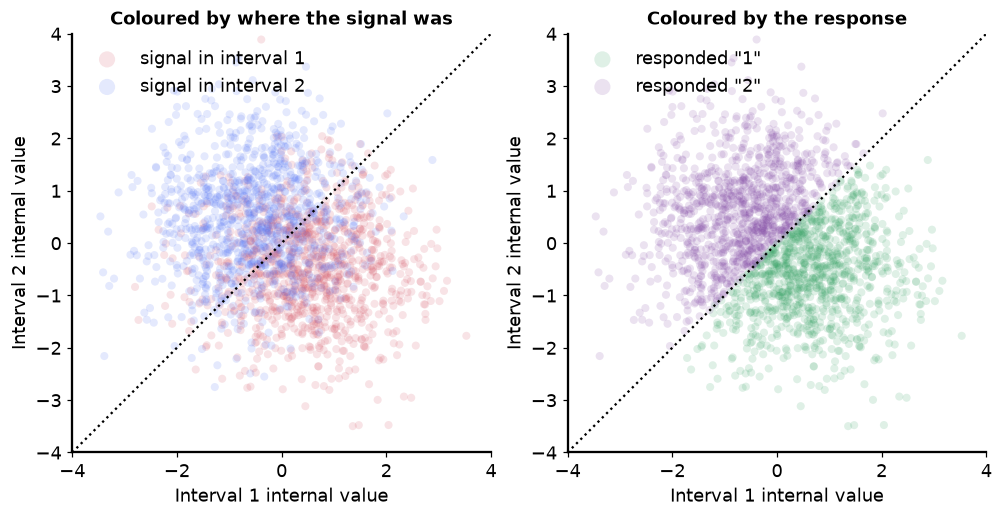

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"
SIGNAL = "#d1495b"
CRIT   = "#333333"

from scipy.stats import norm

# every trial the observer sees TWO intervals, each affected by independent noise
ntrials = 2000
noise_mean, noise_sd = -0.5, 1
signal_strength = 1     # 👈 how far the signal shifts the interval that contains it

rng = np.random.default_rng()
interval1 = rng.standard_normal(ntrials) * noise_sd + noise_mean
interval2 = rng.standard_normal(ntrials) * noise_sd + noise_mean

half = ntrials // 2
interval1[:half] += signal_strength   # first half: signal is in interval 1
interval2[half:] += signal_strength   # second half: signal is in interval 2

# the observer responds "1" if interval 1 felt stronger than interval 2
responses = interval1 > interval2

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9, 4.6), constrained_layout=True)

# left: coloured by which interval actually held the signal
axL.scatter(interval1[:half], interval2[:half], 28, color=SIGNAL, alpha=0.15,
            edgecolors="none", label="signal in interval 1")
axL.scatter(interval1[half:], interval2[half:], 28, color=NOISE, alpha=0.15,
            edgecolors="none", label="signal in interval 2")
axL.plot([-4, 4], [-4, 4], "k:")
axL.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="Interval 1 internal value",
        ylabel="Interval 2 internal value", title="Coloured by where the signal was")
axL.set_aspect("equal"); axL.legend(markerscale=2, loc="upper left")

# right: coloured by the observer's response (which side of the diagonal)
axR.scatter(interval1[responses],  interval2[responses],  28, color="#2a9d5c",
            alpha=0.15, edgecolors="none", label='responded "1"')
axR.scatter(interval1[~responses], interval2[~responses], 28, color="#7b3fa0",
            alpha=0.15, edgecolors="none", label='responded "2"')
axR.plot([-4, 4], [-4, 4], "k:")
axR.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="Interval 1 internal value",
        ylabel="Interval 2 internal value", title="Coloured by the response")
axR.set_aspect("equal"); axR.legend(markerscale=2, loc="upper left")
plt.show()


proportion correct  —  yes/no: 0.694   2AFC: 0.773
d-prime yes/no                : 1.015
d-prime 2AFC (uncorrected)    : 1.501
d-prime 2AFC (corrected, /sqrt2): 1.061


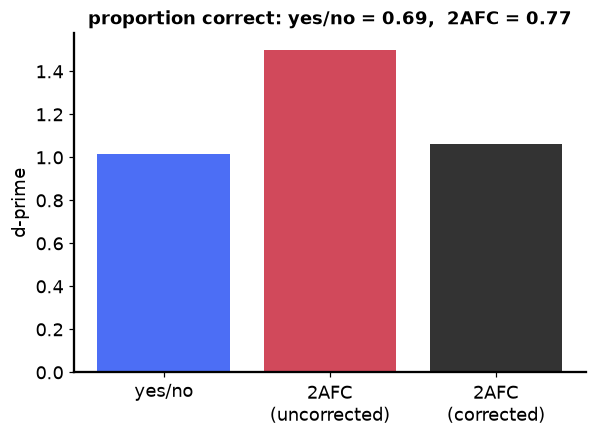

In [2]:
# proportion correct in the 2AFC task
pc_2afc = (np.sum(responses[:half]) + np.sum(~responses[half:])) / ntrials

# pretend the SAME evidence was used in a yes/no task with an ideal criterion at 0
responses_yn = np.concatenate([interval1 > 0, interval2 > 0])
correct_yn = np.concatenate([np.ones(half), np.zeros(half),
                             np.zeros(half), np.ones(half)]).astype(bool)
pc_yn = np.mean(responses_yn == correct_yn)

hit_yn = np.mean(responses_yn[correct_yn])     # yes on signal-present
fa_yn  = np.mean(responses_yn[~correct_yn])    # yes on signal-absent
dprime_yn = norm.ppf(hit_yn) - norm.ppf(fa_yn)

# the same idea for the forced-choice task
hit_2afc = np.mean(responses[:half])           # responded "1" when signal was in 1
fa_2afc  = np.mean(responses[half:])           # responded "1" when signal was in 2
dprime_2afc_uncorrected = norm.ppf(hit_2afc) - norm.ppf(fa_2afc)
dprime_2afc_corrected   = dprime_2afc_uncorrected / np.sqrt(2)

# a short-cut for d-prime in the 2AFC task:
dprime_2afc = np.sqrt(2) * norm.ppf(pc_2afc)

print(f"proportion correct  —  yes/no: {pc_yn:.3f}   2AFC: {pc_2afc:.3f}")
print(f"d-prime yes/no                : {dprime_yn:.3f}")
print(f"d-prime 2AFC (uncorrected)    : {dprime_2afc_uncorrected:.3f}")
print(f"d-prime 2AFC (corrected, /sqrt2): {dprime_2afc_corrected:.3f}")

labels = ["yes/no", "2AFC\n(uncorrected)", "2AFC\n(corrected)"]
plt.figure(figsize=(6, 4))
plt.bar(labels, [dprime_yn, dprime_2afc_uncorrected, dprime_2afc_corrected],
        color=[NOISE, SIGNAL, CRIT])
plt.ylabel("d-prime")
plt.title(f"proportion correct: yes/no = {pc_yn:.2g},  2AFC = {pc_2afc:.2g}")
plt.show()
